# Taste-critic interpretability — Phase C (activation maps) + H1 (off-grid evidence)

What does the taste critic *look at*? This notebook visualizes two things, top-to-bottom:

- **Phase C — activation maps:** hook the critic's Conv1D backbone and show what its channels fire on. We test
  whether specific channels act as **off-grid (16th-offbeat) detectors** that the mean-pin *flood* lights up.
- **H1 — the off-grid evidence (from `critic_saliency_phaseB.py`):** the phase-ablation result, visualized — the
  critic's "fake" evidence lives on off-grid *flooding*, not off-grid notes per se.

Offline numbers + provenance: `notes/taste_critic_saliency_findings.md`. Self-contained — run all cells.
Method note (Phase A gate): we attribute on the **logit margin** `z_real - z_fake`, never the saturated P(real).

In [1]:
import warnings, os, sys
warnings.filterwarnings('ignore'); os.environ['AUDIOREAD_LOG_LEVEL'] = 'ERROR'
from pathlib import Path
import numpy as np, torch, yaml, glob
import matplotlib.pyplot as plt

# find project root (notebook lives in experiments/realism_critic/)
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.utils.reproducibility import set_seed
from src.utils.data_splits import create_data_splits, create_datasets
from src.data.audio_features import AudioFeatureExtractor, AudioFeatureConfig
from src.models import LateFusionClassifier
from src.generation.typed_model import LayeredTypedChartGenerator
from src.generation.typed import pair_holds
from src.generation.playtest_export import enforce_playability
from src.generation.radar_manifold import RadarManifold

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EVAL_SONGS = 8        # small for interactivity; the offline findings used n=12
FOCUS = 0             # which song to feature in the per-song figures
print('device:', device, '| root:', PROJECT_ROOT)

device: cuda | root: /home/ybx/code/stepmania-chart-generator


In [2]:
# ---- models + helpers -------------------------------------------------------
CRITIC   = PROJECT_ROOT / 'checkpoints/realism_critic/best_val.pt'
GEN_CKPT = PROJECT_ROOT / 'checkpoints/gen_motif_full_fixed/best_val.pt'
MANIFOLD = PROJECT_ROOT / 'cache/radar_manifold.npz'

ck = torch.load(CRITIC, map_location=device, weights_only=False)
critic = LateFusionClassifier(ck['config']).to(device); critic.load_state_dict(ck['model_state_dict']); critic.eval()
gen = LayeredTypedChartGenerator(audio_dim=42, d_model=128, num_layers=4, onset_layers=2).to(device)
gen.load_state_dict(torch.load(GEN_CKPT, map_location=device)['model_state_dict'], strict=False); gen.eval()
manifold = RadarManifold.load(MANIFOLD)

def to_binary(t):
    t = np.asarray(t); return ((t == 1) | (t == 2) | (t == 4)).astype(np.float32)

def margin(audio, chart, mask):
    lo = critic(audio, chart, mask); lo = lo['logits'] if isinstance(lo, dict) else lo
    return lo[:, 1] - lo[:, 0]          # logit margin (Phase A: never the saturated P(real))

def phase_masks(T):
    t = np.arange(T)
    return np.isin(t % 4, [0, 2]), np.isin(t % 4, [1, 3])   # (on-grid = quarter/8th, off-grid = 16th-offbeat)

print('critic pooling:', ck['config'].get('pooling_type'), '| backbone fusion_dim:', ck['config'].get('fusion_dim'))

critic pooling: mean_max | backbone fusion_dim: 256


In [3]:
# ---- load val songs + the current-machinery decode (mirrors eval_chaos_mechanism / scripts/generate.py) ----
ext = AudioFeatureExtractor(AudioFeatureConfig(use_chroma=True, use_hpss_onsets=True,
                                               use_metric_phase=True, use_highres_onset=True))
cf = glob.glob(str(PROJECT_ROOT / 'data/**/*.sm'), recursive=True) + glob.glob(str(PROJECT_ROOT / 'data/**/*.ssc'), recursive=True)
_, val_files, _ = create_data_splits(cf, random_state=42)
msl = yaml.safe_load(open(PROJECT_ROOT / 'config/model_config.yaml'))['classifier']['max_sequence_length']
_, val_ds, _ = create_datasets(train_files=[], val_files=val_files, test_files=[], audio_dir=str(PROJECT_ROOT / 'data'),
                               max_sequence_length=msl, feature_extractor=ext, cache_dir=str(PROJECT_ROOT / 'cache/samples_v3'))
val_ds.warm_cache(show_progress=False)
mean_radar = np.mean([m['groove_radar'].to_vector() for m in val_ds.valid_samples if 'groove_radar' in m], 0).astype(np.float32)

songs = []
for i in range(len(val_ds)):
    if len(songs) >= EVAL_SONGS: break
    s = val_ds[i]; meta = val_ds.valid_samples[i]; T = min(int(s['mask'].sum().item()), 768)
    if T < 128: continue
    nd = next((n for n in meta['chart'].note_data if n.difficulty_name == meta['difficulty_name']
               and n.difficulty_value == meta['difficulty_value']), None)
    if nd is None: continue
    tf = to_binary(val_ds.parser.convert_to_tensor_typed(meta['chart'], nd)[:T])
    songs.append({'audio': s['audio'][:T].numpy().astype(np.float32), 'real': tf,
                  'difficulty': int(meta['difficulty_class']), 'bpm': float(meta['chart'].bpm), 'T': T})
print(f'loaded {len(songs)} songs')

def decode(s, radar_vec, density, guidance=1.5, fatigue_penalty=2.0):
    a = torch.from_numpy(s['audio']).unsqueeze(0).to(device); d = torch.tensor([s['difficulty']], device=device)
    radar = torch.from_numpy(np.asarray(radar_vec, np.float32)).unsqueeze(0).to(device)
    with torch.no_grad():
        mem = gen.encode_audio(a); ol = gen.onset_logits(mem, d, radar=radar, style=None)[0]
        if guidance != 1.0:
            ol_u = gen.onset_logits(mem, d, radar=None, style=None)[0]; ol = ol_u + guidance * (ol - ol_u)
        p = torch.sigmoid(ol).cpu().numpy()
    tau = float(np.quantile(p, 1 - density)) if density and density > 0 else 0.5
    gk = dict(onset_threshold=tau, type_sample=True, pattern_sample=True, pattern_temperature=0.7, max_jack_run=2,
              fatigue_penalty=fatigue_penalty, bpm=s['bpm'], radar=radar, style=None, guidance_scale=guidance)
    enforce_playability(gk, override_reason=None)
    with torch.no_grad():
        g = gen.generate(a, d, lengths=torch.tensor([s['T']], device=device), **gk)[0].cpu().numpy()
    return to_binary(pair_holds(g[:s['T']]))

def build_quartet(s):
    mp = mean_radar.copy(); mp[4] = 0.9                                  # OLD mean-pin chaos request (off-manifold)
    mf, mfi = manifold.build_target('chaos=q0.85', s['difficulty'])      # NEW in-distribution chaos
    bv, bi = manifold.build_target('', s['difficulty'])                  # base
    return {'REAL': s['real'], 'BASE': decode(s, bv, bi['density']),
            'MANIFOLD': decode(s, mf, mfi['density']),
            'MEANPIN': decode(s, mp, manifold.target_density(mp, s['difficulty']))}

quartets = [build_quartet(s) for s in songs]
print('built quartets for', len(quartets), 'songs')

Data splits created:
  Train: 4452 files (70.0%)
  Val:   954 files (15.0%)
  Test:  954 files (15.0%)
Parsing 0 chart files...

Dataset initialized with 0 valid samples
Cache: 0/0 samples (0.0% hit rate)
Parsing 954 chart files...


See Me Now failed song length requirement
永遠なる絆と想いのキセキ failed bpm requirement (avg_bpm=270.8)
扉ひらいて、ふたり未来へ-Fantom Euro Mix- failed song length requirement
恋ひ恋ふ縁 Ex failed valid chart requirement (no dance-single charts)
Natsuzora failed song length requirement
Beat your Heart failed bpm requirement (avg_bpm=220.0)
SUPER SUMMER DIVE!! failed song length requirement
Error processing /home/ybx/code/stepmania-chart-generator/data/community/remi/âcü[âfâBü[üÜ/âcü[âfâBü[üÜ.ssc: Audio file not found: /home/ybx/code/stepmania-chart-generator/data/community/remi/âcü[âfâBü[üÜ/c[fB[.mp3
Error processing /home/ybx/code/stepmania-chart-generator/data/community/remi/GHOSTü~GRADUATION/GHOSTü~GRADUATION.ssc: Audio file not found: /home/ybx/code/stepmania-chart-generator/data/community/remi/GHOSTü~GRADUATION/GHOST~GRADUATION.mp3
Crazy Baby failed bpm requirement (avg_bpm=441.1)
Pure My Voices failed song length requirement
Little bravery failed song length requirement
Imaginary affair failed song length

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


トラウマ催眠少女さとり！ failed bpm requirement (avg_bpm=210.0)
Quon failed song length requirement
Error processing /home/ybx/code/stepmania-chart-generator/data/community/remi/è¬Äqé╠âpü[âtâFâNâgâGâîâKâôâgï│Ä║/è¬Äqé╠âpü[âtâFâNâgâGâîâKâôâgï│Ä║.sm: Audio file not found: /home/ybx/code/stepmania-chart-generator/data/community/remi/è¬Äqé╠âpü[âtâFâNâgâGâîâKâôâgï│Ä║/q̃p[tFNgGKg.mp3
Lambda Driver failed song length requirement
Scarlet Double Dance failed song length requirement
ロストワンの号哭 failed song length requirement
Error processing /home/ybx/code/stepmania-chart-generator/data/community/remi/ë╘é╤éτé╞éΦé┌é±/ë╘é╤éτé╞éΦé┌é±.ssc: Audio file not found: /home/ybx/code/stepmania-chart-generator/data/community/remi/ë╘é╤éτé╞éΦé┌é±/ԂтƂڂ.mp3
Edge of glory failed song length requirement
幽雅に咲かせ、墨染の桜 failed song length requirement
memoria ficta failed bpm requirement (avg_bpm=250.0)
しぇる☆どっきんぐ ～だめ！このままじゃ溢れちゃう！～ failed song length requirement
F failed song length requirement
Memories of Sky -CoolDownMIX- failed song 

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?
[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?
[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


...

VG (Radio Edit) failed song length requirement
エチュード failed bpm requirement (avg_bpm=226.0)
GO BACK 2 YOUR RAVE failed song length requirement
Pangaea failed song length requirement
MANIERA failed bpm requirement (avg_bpm=208.0)
縦連打体操第一 failed bpm requirement (avg_bpm=210.5)
サキガツモル failed song length requirement
You Cannot Use the Double Gulp Cup failed bpm requirement (avg_bpm=215.9)
どーっちどっちの歌 failed song length requirement
夜桜 failed song length requirement
Odin failed song length requirement
naTivEfAcE failed song length requirement
Error processing /home/ybx/code/stepmania-chart-generator/data/community/sabo/ZETA SEKAI/ZETA SEKAI.sm: Audio file not found: /home/ybx/code/stepmania-chart-generator/data/community/sabo/ZETA SEKAI/ZETA`f̐Eƒzҁ`.mp3
Error processing /home/ybx/code/stepmania-chart-generator/data/community/sabo/Yure Yeogakseon/Yure Yeogakseon.sm: Audio file not found: /home/ybx/code/stepmania-chart-generator/data/community/sabo/Yure Yeogakseon/08. 幽霊客船の時空を越えた旅.mp3
Plan 8 fai

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?
[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


Madness March Kamikaze failed bpm requirement (avg_bpm=2467.2)
DISCHARGE RUSH failed bpm requirement (avg_bpm=208.0)
HANAJI failed bpm requirement (avg_bpm=232.0)
Plan 8 failed bpm requirement (avg_bpm=212.0)
Now failed song length requirement
Error processing /home/ybx/code/stepmania-chart-generator/data/community/remi/Éié▀üIâCâbâXâôîRÆc -Rebellion of the Dwarfs-/basic.sm: Audio file not found: /home/ybx/code/stepmania-chart-generator/data/community/remi/Éié▀üIâCâbâXâôîRÆc -Rebellion of the Dwarfs-/i߁ICbXRc -Rebellion of the Dwarfs- [EXH].mp3
アンダーハンデッド・ガール failed song length requirement
Mario Paint (Time Regression Mix for BMS) failed song length requirement
Remilia ～吸血鬼の為の協奏曲 failed song length requirement
MAX 360 failed bpm requirement (avg_bpm=360.2)
創傷イノセンス failed bpm requirement (avg_bpm=205.0)
Error processing /home/ybx/code/stepmania-chart-generator/data/community/Areicia Favorite Song Pack 1st Volume/水橋ジェラシックパーク/水橋ジェラシックパーク.sm: Audio file not found: /home/ybx/code/stepmania-ch

Central Nucleus failed song length requirement
Super Kamehameha failed song length requirement
Parousia failed song length requirement
Error processing /home/ybx/code/stepmania-chart-generator/data/community/sabo/ppp/p.sm: Audio file not found: /home/ybx/code/stepmania-chart-generator/data/community/sabo/ppp/{[_[YI.mp3
FUCK YOU failed bpm requirement (avg_bpm=426.5)
CHAINSAW PARTY (Wind God Girl remix) failed song length requirement
Error processing /home/ybx/code/stepmania-chart-generator/data/community/Sanatenshin/ZoNE-iT/ZoNE-iT.sm: Audio file not found: /home/ybx/code/stepmania-chart-generator/data/community/Sanatenshin/ZoNE-iT/ZoNe-iT.mp3
黒猫円舞曲 failed bpm requirement (avg_bpm=209.8)
Alastor failed song length requirement
HesitationSnow Ex failed song length requirement
Error processing /home/ybx/code/stepmania-chart-generator/data/community/sabo/1233333333333335/1233333333333335.sm: Audio file not found: /home/ybx/code/stepmania-chart-generator/data/community/sabo/1233333333333335

built quartets for 8 songs



## Phase C — activation maps

Hook the Conv1D backbone (output `(B, T, 256)` — the per-frame representation the pooling reads) and ask:
**do specific channels respond to off-grid content that the mean-pin flood produces?**

> **Read Phase C as corroboration, not proof.** A naive `corr(activation, off-grid-indicator)` is confounded —
> the indicator is periodic, so any metric-grid-tracking channel correlates with it on *any* chart. We instead use
> a **note-conditioned** contrast (off-grid vs on-grid *note* frames, within the flood). The **causal** evidence
> that off-grid content is the fake signal is the **H1 ablation** further down, not these activations.

In [4]:
# forward hook on the backbone -> capture (T, C) per-frame activations
_acts = {}
def _hook(mod, inp, out): _acts['b'] = out.detach()
_handle = critic.backbone.register_forward_hook(_hook)

def backbone_acts(s, chart_np):
    T = s['T']
    a = torch.from_numpy(s['audio'][:, :23]).unsqueeze(0).to(device)
    c = torch.from_numpy(chart_np).unsqueeze(0).to(device); m = torch.ones(1, T, device=device)
    with torch.no_grad(): _ = margin(a, c, m)
    return _acts['b'][0, :T].cpu().numpy()      # (T, 256)

s = songs[FOCUS]; T = s['T']; on, off = phase_masks(T)
A = {k: backbone_acts(s, quartets[FOCUS][k]) for k in quartets[FOCUS]}
print('focus song: diff', s['difficulty'], '| T', T, '| backbone act shape', A['REAL'].shape)

focus song: diff 3 | T 768 | backbone act shape (768, 256)


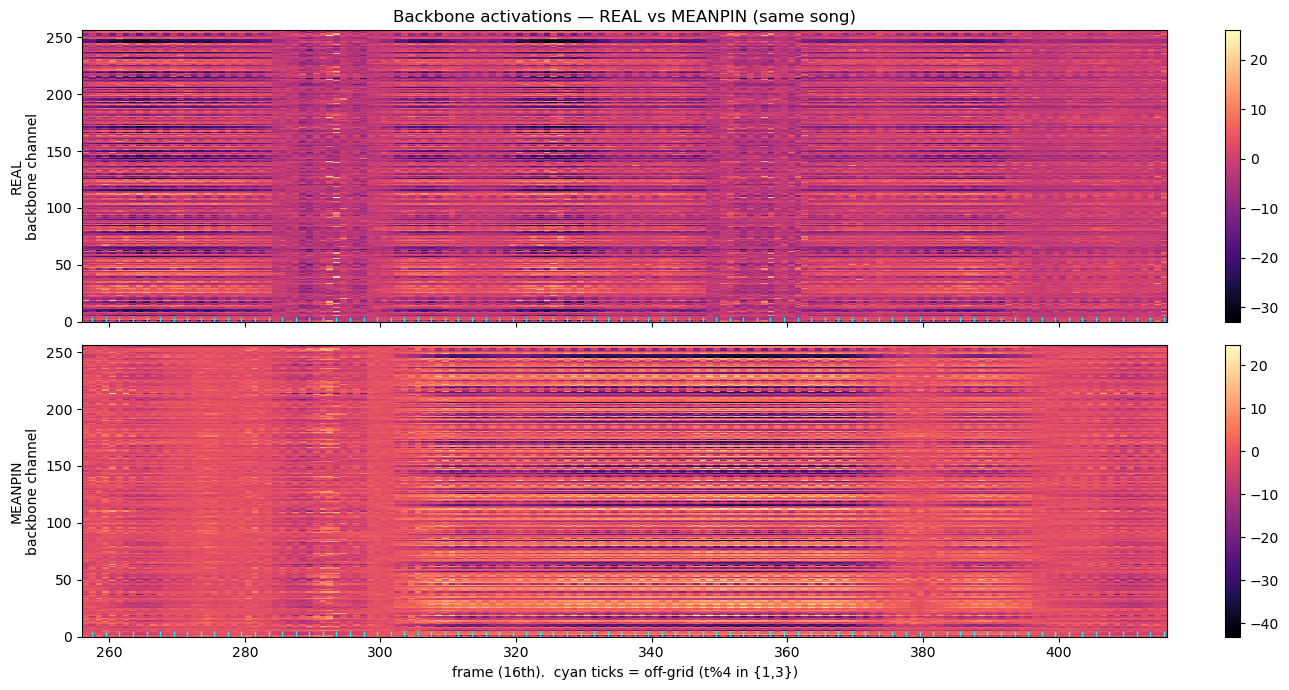

In [5]:
# Fig 1 — backbone activation heatmaps (channels x time), REAL vs MEANPIN, on a window
w0, w1 = T // 3, T // 3 + 160                                   # a readable time window
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, k in zip(axes, ['REAL', 'MEANPIN']):
    im = ax.imshow(A[k][w0:w1].T, aspect='auto', cmap='magma', interpolation='nearest',
                   extent=[w0, w1, 0, A[k].shape[1]])
    ax.set_ylabel(f'{k}\nbackbone channel'); fig.colorbar(im, ax=ax, fraction=0.02)
    for t in range(w0, w1):                                     # tick off-grid frames along the bottom
        if t % 4 in (1, 3): ax.plot([t + 0.5], [2], marker='|', color='cyan', ms=4)
axes[-1].set_xlabel('frame (16th).  cyan ticks = off-grid (t%4 in {1,3})')
axes[0].set_title('Backbone activations — REAL vs MEANPIN (same song)')
plt.tight_layout(); plt.show()

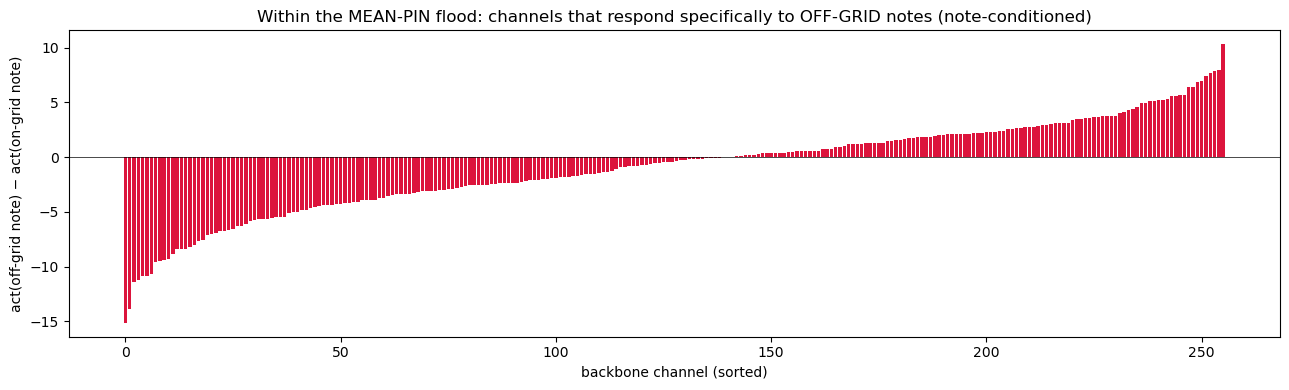

top off-grid-content channel on MEANPIN: #121  (off−on note activation Δ = +10.30)
NOTE: this is CORROBORATIVE/illustrative. The CAUSAL proof that off-grid content is the fake evidence is
the H1 ablation below (removing off-grid notes raises the margin) — not this activation correlation.


In [6]:
# Fig 2 — NOTE-CONDITIONED off-grid response (avoids the periodic-indicator confound).
# A raw corr(activation, off-grid-indicator) is confounded: the indicator is periodic, so ANY grid-tracking
# channel correlates with it on ANY chart (REAL included). Instead, WITHIN the mean-pin flood, compare each
# channel's mean activation on off-grid NOTE frames vs on-grid NOTE frames -> a genuine off-grid-CONTENT detector
# fires more on the former. (Conditioning on notes removes the empty-frame periodicity.)
def note_conditioned_offgrid(act, chart, T):
    on, off = phase_masks(T); notes = chart.any(1)
    fon, foff = notes & on, notes & off
    if foff.sum() < 5 or fon.sum() < 5:
        return None
    return act[foff].mean(0) - act[fon].mean(0)               # (C,) off-note minus on-note activation

dmp = note_conditioned_offgrid(A['MEANPIN'], quartets[FOCUS]['MEANPIN'], T)   # MEANPIN has both -> defined
order = np.argsort(dmp)
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(np.arange(len(order)), dmp[order], color='crimson')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('backbone channel (sorted)'); ax.set_ylabel('act(off-grid note) − act(on-grid note)')
ax.set_title('Within the MEAN-PIN flood: channels that respond specifically to OFF-GRID notes (note-conditioned)')
plt.tight_layout(); plt.show()
top = order[-1]
print(f'top off-grid-content channel on MEANPIN: #{top}  (off−on note activation Δ = {dmp[top]:+.2f})')
print('NOTE: this is CORROBORATIVE/illustrative. The CAUSAL proof that off-grid content is the fake evidence is')
print('the H1 ablation below (removing off-grid notes raises the margin) — not this activation correlation.')

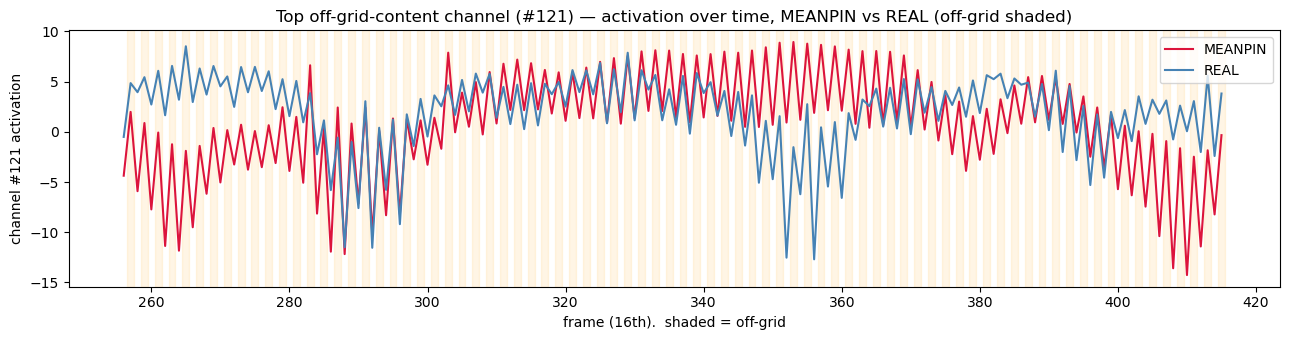

In [7]:
# Fig 3 — the top off-grid channel's activation trace over time, MEANPIN vs REAL, off-grid frames shaded
fig, ax = plt.subplots(figsize=(13, 3.5))
tt = np.arange(w0, w1)
ax.plot(tt, A['MEANPIN'][w0:w1, top], color='crimson', label='MEANPIN')
ax.plot(tt, A['REAL'][w0:w1, top], color='steelblue', label='REAL')
for t in tt:
    if t % 4 in (1, 3): ax.axvspan(t - 0.5, t + 0.5, color='orange', alpha=0.10)
ax.set_xlabel('frame (16th).  shaded = off-grid'); ax.set_ylabel(f'channel #{top} activation')
ax.legend(); ax.set_title(f'Top off-grid-content channel (#{top}) — activation over time, MEANPIN vs REAL (off-grid shaded)')
plt.tight_layout(); plt.show()

## H1 — the off-grid evidence (phase ablation)

The validated perturbation (Phase A): remove all **off-grid** notes vs all **on-grid** notes and watch the logit
margin. If removing off-grid notes *raises* the margin (recovers "realness"), the fake evidence is off-grid.

In [8]:
import pandas as pd
def analyze(s, chart_np):
    T = s['T']; on, off = phase_masks(T); notes = chart_np.any(1); n = int(notes.sum())
    a = torch.from_numpy(s['audio'][:, :23]).unsqueeze(0).to(device); m = torch.ones(1, T, device=device)
    with torch.no_grad():
        base = margin(a, torch.from_numpy(chart_np).unsqueeze(0).to(device), m).item()
        no_off = chart_np.copy(); no_off[off] = 0.0
        no_on = chart_np.copy(); no_on[on] = 0.0
        m_no_off = margin(a, torch.from_numpy(no_off).unsqueeze(0).to(device), m).item()
        m_no_on = margin(a, torch.from_numpy(no_on).unsqueeze(0).to(device), m).item()
    return dict(margin=base, off_frac=(notes & off).sum() / max(n, 1),
                d_off=m_no_off - base, d_on=m_no_on - base)

recs = []
for s, q in zip(songs, quartets):
    for k, chart in q.items():
        r = analyze(s, chart); r['rung'] = k; recs.append(r)
df = pd.DataFrame(recs)
summary = df.groupby('rung')[['margin', 'off_frac', 'd_off', 'd_on']].mean().reindex(['REAL', 'BASE', 'MANIFOLD', 'MEANPIN'])
print(summary.round(2))
print('\ncross-chart corr(margin, off_frac) = %.3f' % df['margin'].corr(df['off_frac']))

          margin  off_frac  d_off  d_on
rung                                   
REAL        1.78      0.00  -0.02 -4.65
BASE       -1.48      0.00   0.00 -1.15
MANIFOLD   -2.48      0.00   0.00 -0.16
MEANPIN    -5.03      0.83   2.08  0.31

cross-chart corr(margin, off_frac) = -0.510


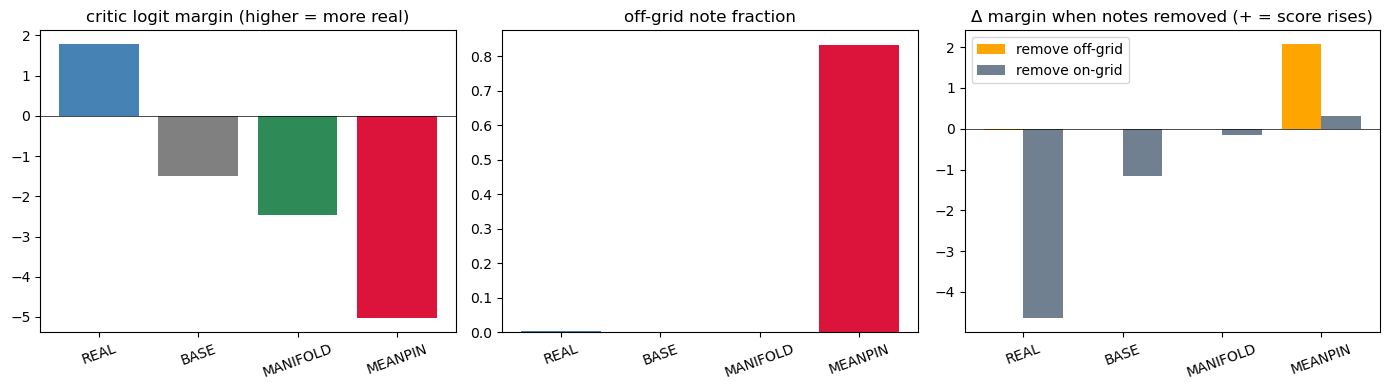

In [9]:
# Fig 4 — H1 summary bars
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = {'REAL': 'steelblue', 'BASE': 'gray', 'MANIFOLD': 'seagreen', 'MEANPIN': 'crimson'}
rungs = ['REAL', 'BASE', 'MANIFOLD', 'MEANPIN']; cs = [colors[r] for r in rungs]
axes[0].bar(rungs, summary['margin'], color=cs); axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('critic logit margin (higher = more real)')
axes[1].bar(rungs, summary['off_frac'], color=cs); axes[1].set_title('off-grid note fraction')
x = np.arange(len(rungs))
axes[2].bar(x - 0.2, summary['d_off'], width=0.4, label='remove off-grid', color='orange')
axes[2].bar(x + 0.2, summary['d_on'], width=0.4, label='remove on-grid', color='slategray')
axes[2].axhline(0, color='k', lw=0.5); axes[2].set_xticks(x); axes[2].set_xticklabels(rungs)
axes[2].set_title('Δ margin when notes removed (+ = score rises)'); axes[2].legend()
for ax in axes: ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

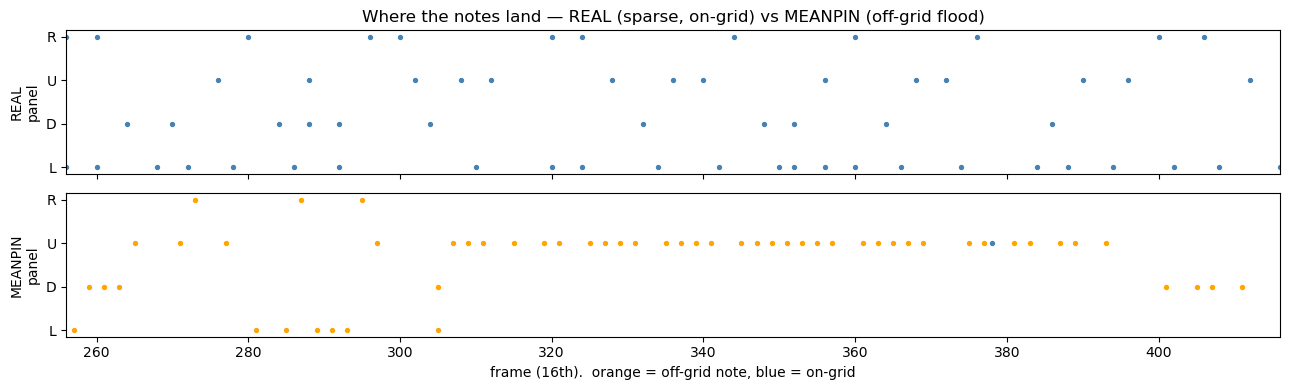

In [10]:
# Fig 5 — the flood, visualized: note positions over time, REAL vs MEANPIN, off-grid notes in orange
fig, axes = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
for ax, k in zip(axes, ['REAL', 'MEANPIN']):
    ch = quartets[FOCUS][k]; on, off = phase_masks(T)
    for panel in range(4):
        idx = np.where(ch[:, panel] > 0)[0]
        og = np.isin(idx % 4, [1, 3])
        ax.scatter(idx[~og], np.full((~og).sum(), panel), s=8, color='steelblue')
        ax.scatter(idx[og], np.full(og.sum(), panel), s=8, color='orange')
    ax.set_ylabel(f'{k}\npanel'); ax.set_yticks(range(4)); ax.set_yticklabels(['L', 'D', 'U', 'R'])
    ax.set_xlim(w0, w1)
axes[-1].set_xlabel('frame (16th).  orange = off-grid note, blue = on-grid')
axes[0].set_title('Where the notes land — REAL (sparse, on-grid) vs MEANPIN (off-grid flood)')
plt.tight_layout(); plt.show()
_handle.remove()   # detach the backbone hook

## Takeaways

- **Phase C (corroborative):** within the mean-pin flood, some backbone channels respond specifically to
  **off-grid note** frames (Figs 1–3, note-conditioned to avoid the periodic-indicator confound). Suggestive that
  the representation encodes the on-grid/off-grid distinction — but the causal claim rests on H1, not this.
- **H1:** removing **off-grid** notes *raises* MEANPIN's margin (recovers ~half its gap), while removing the
  **on-grid backbone** tanks REAL — the fake evidence is off-grid **flooding** (Fig 4). But it is **not
  off-grid-phobic**: REAL's sparse off-grid notes are tasteful (removing them *hurts*). Fig 5 shows the flood
  directly.
- **Why it matters:** the taste critic and the chaos-conditioning redesign agree on the **same axis** — staying
  on the groove manifold means not flooding off-grid, which is exactly what the critic rewards. See
  `notes/taste_critic_saliency_findings.md`.